# Точность границ Чебышёва и Чернова для суммы независимых двоичных величин

**Автор:** Дмитрий Багацкий  
**Дисциплина:** Теория информации  
**Раздел курса:** первая часть, лекции 1–5

## Связь с задачами курса

Работа развивает задачи 3.3–3.6 из указанного в задании сборника «Задачи ТИнф»: границу Чебышёва через дисперсию, её применение к среднему и двоичным величинам, а также границу Чернова. Файл задачника в репозитории отсутствует, поэтому дословные формулировки не воспроизводятся.

В исходных задачах выводятся вероятностные границы. Здесь исследуется их точность и информативность при конечном числе испытаний.

### Аннотация

Для суммы независимых величин Бернулли точная вероятность отклонения вычисляется по биномиальному распределению и сравнивается с границами Чебышёва и Чернова. Исследуется зависимость качества оценок от числа испытаний, параметра источника и величины отклонения. Отдельно рассматриваются асимметрия хвостов и влияние дискретности. Случайное моделирование не используется.

## 1. Постановка и исследовательские вопросы

Пусть $X_1,\ldots,X_n\sim\operatorname{Bernoulli}(p)$, $0<p<1$, независимы и одинаково распределены. Обозначим
$$
K_n=\sum_{i=1}^nX_i,\qquad \overline X_n=\frac{K_n}{n}.
$$
Исследуется
$$
P_{\mathrm{exact}}(n,p,\delta)=\mathsf P(|\overline X_n-p|\geq\delta).
$$

1. Насколько каждая граница завышает точную вероятность?
2. Как точность зависит от $n,p,\delta$?
3. Где границы неинформативны?
4. Как различаются хвосты при $p\neq0.5$?
5. Как дискретность влияет на точную вероятность?

## 2. Теоретические границы

Из $\mathsf E[X_i]=p$, $\operatorname{Var}(X_i)=p(1-p)$ следуют
$$
\mathsf E[\overline X_n]=p,\qquad \operatorname{Var}(\overline X_n)=\frac{p(1-p)}n.
$$
Неравенство Чебышёва даёт
$$
B_{\mathrm{Cheb,raw}}=\frac{p(1-p)}{n\delta^2},\qquad B_{\mathrm{Cheb}}=\min(1,B_{\mathrm{Cheb,raw}}).
$$
Исходное значение не меньше единицы не даёт нетривиального ограничения.

Так как $K_n\sim\operatorname{Bin}(n,p)$, для нестрогого события
$$
k_-=\lfloor n(p-\delta)\rfloor,\quad k_+=\lceil n(p+\delta)\rceil,
$$
$$
P_{\mathrm{exact}}=\mathsf P(K_n\leq k_-)+\mathsf P(K_n\geq k_+).
$$
Пороги вне носителя соответствуют невозможным хвостам. Числа около целых распознаются с допуском $10^{-12}$.

Для Чернова $\mathsf E[e^{tK_n}]=(1-p+pe^t)^n$. Применение неравенства Маркова и оптимизация по $t$ приводят к
$$
D_2(q\Vert p)=q\log_2\frac qp+(1-q)\log_2\frac{1-q}{1-p}.
$$
При $q>p$: $\mathsf P(\overline X_n\geq q)\leq2^{-nD_2(q\Vert p)}$; при $q<p$ аналогична нижняя оценка. Поэтому
$$
B_{\mathrm{Chernoff,raw}}=2^{-nD_2(p-\delta\Vert p)}+2^{-nD_2(p+\delta\Vert p)},
\quad B_{\mathrm{Chernoff}}=\min(1,B_{\mathrm{Chernoff,raw}}).
$$
Используются именно пороги $p\pm\delta$, а $2^{-nD_2}=e^{-nD_{\mathrm{nat}}}$.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import xlogy
from scipy.stats import binom
from IPython.display import display, Markdown

TOL=1e-12
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns",30)
pd.set_option("display.float_format",lambda x:f"{x:.6g}")

## 3. Реализация вычислений

Нижний хвост вычисляется через `binom.cdf`, верхний — через `binom.sf`, без вычитания из единицы. Двусторонняя вероятность равна сумме хвостов. Границы Чернова вычисляются непосредственно как $2^{-nD_2}$, а коэффициенты завышения — как отношение границы к точной вероятности. Округление порогов с допуском сохраняет включение граничных значений события.

In [2]:
def validate_parameters(n:int,p:float,delta:float)->None:
    """Проверяет параметры биномиального эксперимента."""
    if not isinstance(n,(int,np.integer)) or n<1: raise ValueError("n должно быть положительным целым")
    if not 0<p<1: raise ValueError("p должно лежать в (0,1)")
    if not delta>0 or not math.isfinite(delta): raise ValueError("delta должно быть положительным")

def snap_near_integer(x:float,tol:float=TOL)->float:
    """Заменяет число ближайшим целым только в пределах tol."""
    nearest=round(x)
    return float(nearest) if abs(x-nearest)<=tol else float(x)

def integer_thresholds(n:int,p:float,delta:float)->tuple[int,int]:
    """Возвращает включённые пороги нижнего и верхнего хвостов."""
    validate_parameters(n,p,delta)
    return math.floor(snap_near_integer(n*(p-delta))),math.ceil(snap_near_integer(n*(p+delta)))

def bernoulli_divergence_bits(q:float,p:float)->float:
    """Вычисляет D_2(Ber(q)||Ber(p)) в битах."""
    if not 0<=q<=1 or not 0<p<1: raise ValueError("Нужны q в [0,1], p в (0,1)")
    return float((xlogy(q,q/p)+xlogy(1-q,(1-q)/(1-p)))/math.log(2))

def exact_tails(n:int,p:float,delta:float)->dict[str,float]:
    """Вычисляет точные биномиальные хвосты и их сумму."""
    kl,kh=integer_thresholds(n,p,delta)
    lower=float(binom.cdf(kl,n,p))
    upper=float(binom.sf(kh-1,n,p))
    return {"k_low":kl,"k_high":kh,"lower":lower,"upper":upper,
            "probability":min(1.0,lower+upper)}

def chebyshev_bound(n:int,p:float,delta:float)->float:
    """Возвращает ограниченную единицей границу Чебышёва."""
    validate_parameters(n,p,delta)
    return min(1.0,p*(1-p)/(n*delta**2))

def chernoff_bound(n:int,p:float,delta:float)->dict[str,float]:
    """Вычисляет две границы хвостов Чернова и их сумму."""
    validate_parameters(n,p,delta)
    def tail(q:float)->float:
        return 2.0**(-n*bernoulli_divergence_bits(q,p)) if 0<=q<=1 else 0.0
    lower=tail(p-delta)
    upper=tail(p+delta)
    return {"lower":lower,"upper":upper,"bound":min(1.0,lower+upper)}

def comparison_metrics(n:int,p:float,delta:float)->dict[str,float]:
    """Возвращает значения и отношения, используемые в сравнении."""
    probability=exact_tails(n,p,delta)["probability"]
    cheb=chebyshev_bound(n,p,delta)
    chern=chernoff_bound(n,p,delta)["bound"]
    return {"n":n,"p":p,"delta":delta,"probability":probability,
            "cheb":cheb,"chern":chern,
            "cheb_ratio":cheb/probability if probability>0 else math.inf,
            "chern_ratio":chern/probability if probability>0 else math.inf}

## 4. Компактная проверка корректности

Проверки связаны с теорией: симметрией Бернулли, перестановкой хвостов, неотрицательностью дивергенции, целочисленными порогами, прямым суммированием при малом $n$ и выполнением верхних границ.

In [3]:
assert integer_thresholds(10,.3,.1)==(2,4)
assert abs(bernoulli_divergence_bits(.3,.3))<TOL
assert all(bernoulli_divergence_bits(q,.3)>=-TOL for q in np.linspace(0,1,21))

a=exact_tails(100,.2,.05);b=exact_tails(100,.8,.05)
assert abs(a["probability"]-b["probability"])<1e-13
assert abs(a["lower"]-b["upper"])<1e-13 and abs(a["upper"]-b["lower"])<1e-13
s=exact_tails(100,.5,.1)
assert abs(s["lower"]-s["upper"])<1e-13

n,p,delta=12,.25,.1
e=exact_tails(n,p,delta);ks=np.arange(n+1);pmf=binom.pmf(ks,n,p)
direct=float(pmf[ks<=e["k_low"]].sum()+pmf[ks>=e["k_high"]].sum())
assert abs(direct-e["probability"])<1e-14

for p in [.1,.25,.5,.8]:
    for n in [20,100,500]:
        for r in [.1,.3,.7]:
            delta=r*min(p,1-p);z=comparison_metrics(n,p,delta)
            assert 0<=z["probability"]<=1
            assert z["cheb"]+1e-12>=z["probability"]
            assert z["chern"]+1e-12>=z["probability"]
print("Проверены пороги, симметрия, хвосты, дивергенция и обе верхние границы.")

Проверены пороги, симметрия, хвосты, дивергенция и обе верхние границы.


## 5. Зависимость от величины отклонения

Основной пример: $p=0.25$, $n=100$. По горизонтали используется нормированное отклонение $r=\delta/\min(p,1-p)$. В левой панели показаны вероятности, в правой — число десятичных порядков, на которое граница превосходит точное значение.

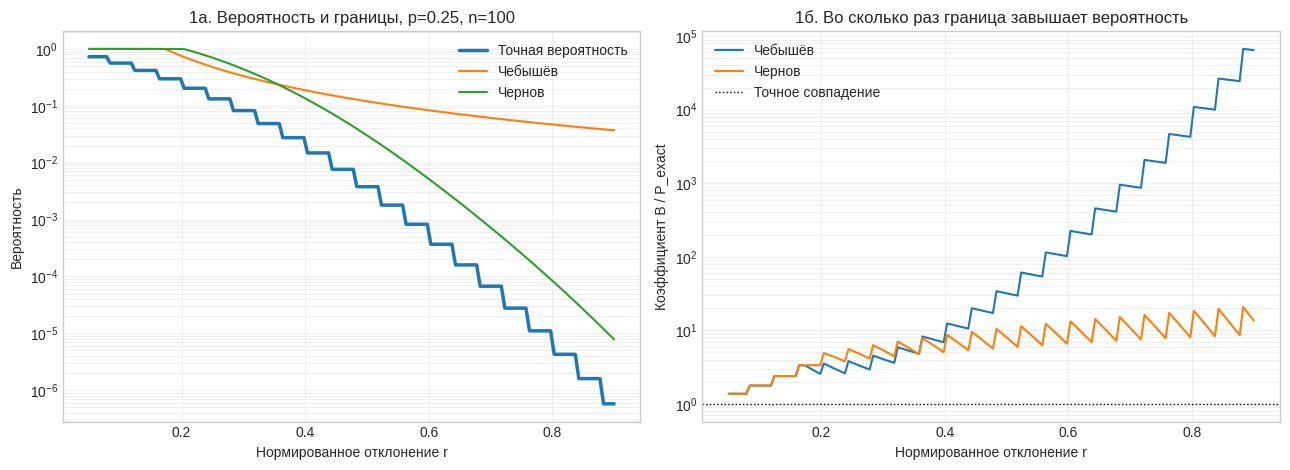

,p,n,delta,probability,cheb,chern,cheb_ratio,chern_ratio
0,0.1,20,0.05,0.7148,1,1,1.399,1.399
1,0.1,100,0.05,0.1301,0.36,0.4823,2.766,3.7059
2,0.25,100,0.05,0.2984,0.75,1,2.5136,3.3515
3,0.25,500,0.05,0.0113,0.15,0.0709,13.2527,6.264
4,0.5,100,0.05,0.3682,1,1,2.7159,2.7159
5,0.5,100,0.1,0.0569,0.25,0.267,4.3946,4.6939


In [4]:
p0,n0=.25,100
r_grid=np.linspace(.05,.9,150)
delta_data=pd.DataFrame([comparison_metrics(n0,p0,r*min(p0,1-p0))|{"r":r} for r in r_grid])

fig,ax=plt.subplots(1,2,figsize=(13,4.8))
ax[0].plot(delta_data.r,delta_data.probability,label="Точная вероятность",linewidth=2.5)
ax[0].plot(delta_data.r,delta_data.cheb,label="Чебышёв")
ax[0].plot(delta_data.r,delta_data.chern,label="Чернов")
ax[0].set_yscale("log")
ax[0].set(xlabel="Нормированное отклонение r",ylabel="Вероятность",
          title="1а. Вероятность и границы, p=0.25, n=100")

ax[1].plot(delta_data.r,delta_data.cheb_ratio,label="Чебышёв")
ax[1].plot(delta_data.r,delta_data.chern_ratio,label="Чернов")
ax[1].axhline(1,color="black",linestyle=":",linewidth=1,label="Точное совпадение")
ax[1].set_yscale("log")
ax[1].set(xlabel="Нормированное отклонение r",ylabel="Коэффициент B / P_exact",
          title="1б. Во сколько раз граница завышает вероятность")
for a in ax:
    a.legend();a.grid(True,which="both",alpha=.3)
plt.tight_layout();plt.show()

selected=[(.1,20,.05),(.1,100,.05),(.25,100,.05),(.25,500,.05),(.5,100,.05),(.5,100,.1)]
comparison_table=pd.DataFrame([comparison_metrics(n,p,d) for p,n,d in selected])
display(comparison_table[["p","n","delta","probability","cheb","chern",
                          "cheb_ratio","chern_ratio"]].round(4))

Ступени точной кривой возникают при переходе порога через целое значение $K_n$. Ограниченные границы сначала равны единице и становятся информативными при достаточно большом отклонении. На графике 1б значение 1 означает точное совпадение, 10 — завышение в 10 раз, 100 — в 100 раз; логарифмическая шкала позволяет одновременно видеть разные порядки величин.

## 6. Зависимость от числа испытаний

Используется общее абсолютное отклонение $\delta=0.05$. Три значения $p$ показаны на отдельных вертикальных панелях одной фигуры. У каждой панели собственная шкала вероятности, поэтому форма кривых остаётся читаемой.

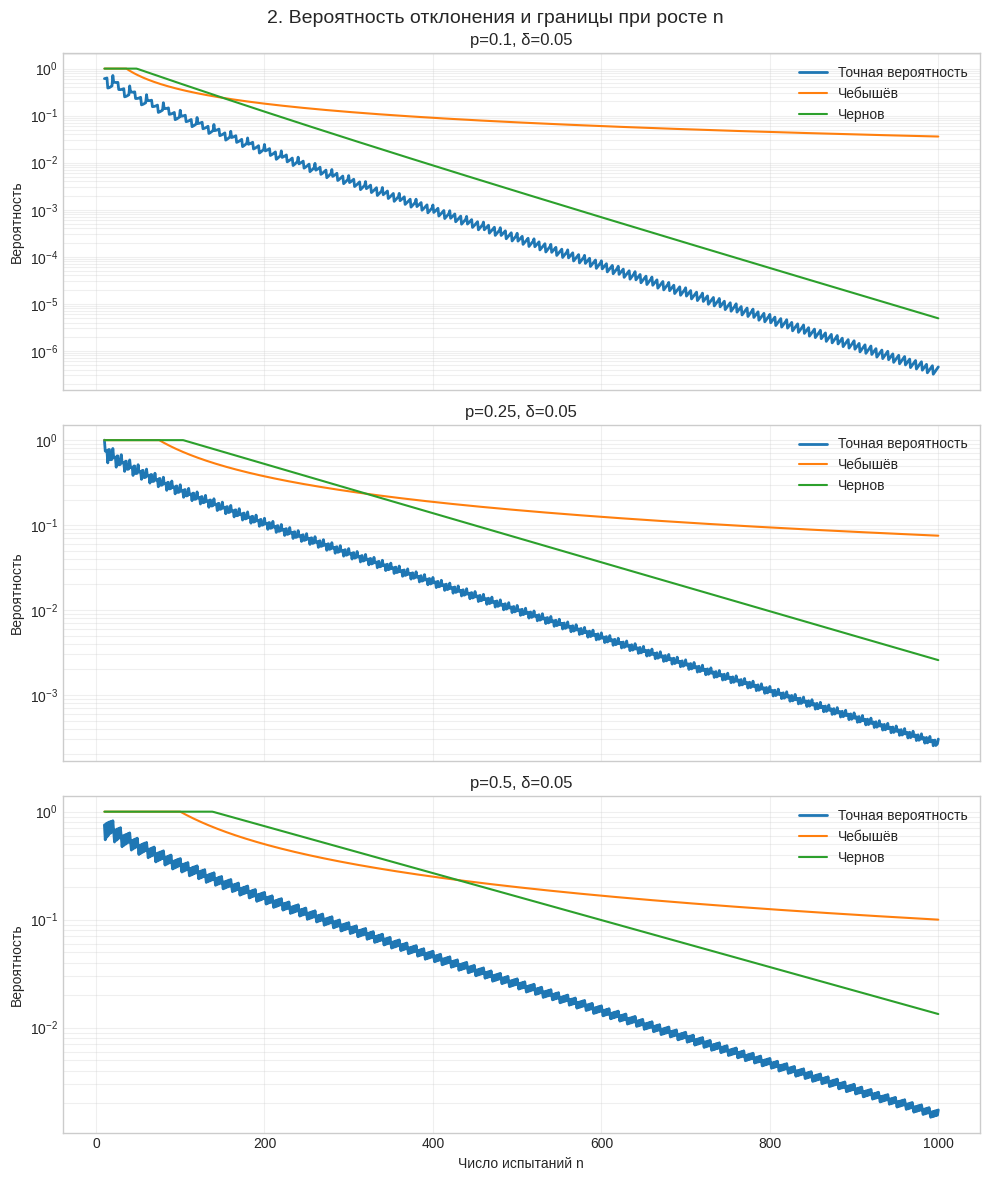

In [5]:
n_grid=np.arange(10,1001)
fig,axes=plt.subplots(3,1,figsize=(10,12),sharex=True)
for ax,p in zip(axes,[.1,.25,.5]):
    curves=np.array([(exact_tails(int(n),p,.05)["probability"],
                      chebyshev_bound(int(n),p,.05),
                      chernoff_bound(int(n),p,.05)["bound"]) for n in n_grid])
    ax.plot(n_grid,curves[:,0],label="Точная вероятность",linewidth=2)
    ax.plot(n_grid,curves[:,1],label="Чебышёв")
    ax.plot(n_grid,curves[:,2],label="Чернов")
    ax.set_yscale("log")
    ax.set_ylabel("Вероятность")
    ax.set_title(f"p={p}, δ=0.05")
    ax.legend(loc="upper right")
    ax.grid(True,which="both",alpha=.3)
axes[-1].set_xlabel("Число испытаний n")
fig.suptitle("2. Вероятность отклонения и границы при росте n",fontsize=14)
plt.tight_layout();plt.show()

Во всех трёх случаях наблюдается общий спад с ростом $n$, но точная вероятность локально колеблется при изменении целочисленных порогов. Чебышёв убывает как $1/n$, тогда как точный хвост и граница Чернова имеют преимущественно экспоненциальный масштаб. Вертикальные панели позволяют сравнить форму ступеней для разных $p$.

## 7. Асимметрия хвостов

Для $p=0.1$, $n=100$ сравниваются точные хвосты и соответствующие односторонние границы Чернова. Используется нормированное отклонение $r$, чтобы оба порога оставались внутри $[0,1]$.

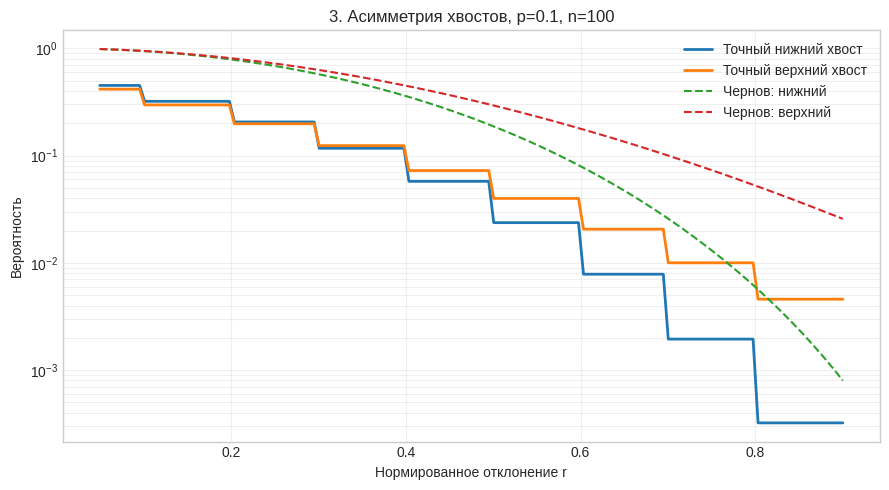

In [6]:
p_tail,n_tail=.1,100
tail_rows=[]
for r in np.linspace(.05,.9,150):
    delta=r*min(p_tail,1-p_tail);ex=exact_tails(n_tail,p_tail,delta);cr=chernoff_bound(n_tail,p_tail,delta)
    tail_rows.append({"r":r,"lower":ex["lower"],"upper":ex["upper"],
                      "chern_lower":cr["lower"],"chern_upper":cr["upper"]})
tails=pd.DataFrame(tail_rows)
plt.figure(figsize=(9,5))
plt.plot(tails.r,tails.lower,label="Точный нижний хвост",linewidth=2)
plt.plot(tails.r,tails.upper,label="Точный верхний хвост",linewidth=2)
plt.plot(tails.r,tails.chern_lower,"--",label="Чернов: нижний")
plt.plot(tails.r,tails.chern_upper,"--",label="Чернов: верхний")
plt.yscale("log");plt.xlabel("Нормированное отклонение r");plt.ylabel("Вероятность")
plt.title("3. Асимметрия хвостов, p=0.1, n=100")
plt.legend();plt.grid(True,which="both",alpha=.3);plt.tight_layout();plt.show()

При $p\neq0.5$ одинаковые отклонения в разные стороны соответствуют разным значениям дивергенции и разным биномиальным хвостам. При замене $p$ на $1-p$ хвосты меняются местами, что подтверждено в проверках.

## 8. Ограничения

Рассматриваются независимые одинаково распределённые испытания Бернулли с известным $p$. Выводы относятся к конечным сеткам параметров. Точные биномиальные вероятности вычисляются численно в обычном представлении; на исследованных сетках хвосты не обнуляются. При существенно более редких событиях потребуются логарифмические вычисления. Чебышёв и Чернов — аналитические верхние оценки, а не статистические оценки по данным. Случайное моделирование не проводится.

## 9. Ответы на исследовательские вопросы и заключение

Следующая ячейка формирует численные ответы из рассчитанных таблиц и сеток.

In [7]:
r_mid=.5
d_mid=r_mid*min(p_tail,1-p_tail)
tail_mid=exact_tails(n_tail,p_tail,d_mid)
tail_ratio=max(tail_mid["lower"],tail_mid["upper"])/min(tail_mid["lower"],tail_mid["upper"])

conclusion=fr"""1. **Точность границ.** В сравнительной таблице максимальные коэффициенты
завышения равны {comparison_table.cheb_ratio.max():.2f} для Чебышёва и
{comparison_table.chern_ratio.max():.2f} для Чернова. На первом графике видны
области, где ограниченные единицей границы неинформативны.

2. **Зависимость от параметров.** При увеличении $n$ точная вероятность в целом снижается,
но может локально возрастать из-за целочисленных порогов. Граница Чебышёва убывает
как $1/n$, а граница Чернова отражает экспоненциальный масштаб.

3. **Асимметрия хвостов.** При $p=0.1$, $n=100$ и $r=0.5$ отношение большего
точного хвоста к меньшему равно {tail_ratio:.2f}. При замене $p$ на $1-p$
хвосты меняются местами.

Работа воспроизводит известные вероятностные оценки на выбранных конечных
сетках параметров."""
display(Markdown(conclusion))

1. **Точность границ.** В сравнительной таблице максимальные коэффициенты
завышения равны 13.25 для Чебышёва и
6.26 для Чернова. На первом графике видны
области, где ограниченные единицей границы неинформативны.

2. **Зависимость от параметров.** При увеличении $n$ точная вероятность в целом снижается,
но может локально возрастать из-за целочисленных порогов. Граница Чебышёва убывает
как $1/n$, а граница Чернова отражает экспоненциальный масштаб.

3. **Асимметрия хвостов.** При $p=0.1$, $n=100$ и $r=0.5$ отношение большего
точного хвоста к меньшему равно 1.26. При замене $p$ на $1-p$
хвосты меняются местами.

Работа воспроизводит известные вероятностные оценки на выбранных конечных
сетках параметров.